In [117]:
# Load cleaned dataset from CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any

df_cleaned = pd.read_csv('/Users/mgarzon/Desktop/Statistics/FinalProject/ai-masters-stats-probability/Untitled/notebooks/df_cleaned.csv')

# Verify the dataset loaded
print("✓ Cleaned dataset loaded successfully")
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

✓ Cleaned dataset loaded successfully
Shape: (41432, 14)
Columns: ['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'income_binary']


2. ANALYSIS - AGE

Age Statistics:
  Mean: 39.44
  Median: 38.00
  Std: 13.64
  Min: 17.00
  Max: 90.00
  Q25: 29.00
  Q75: 49.00


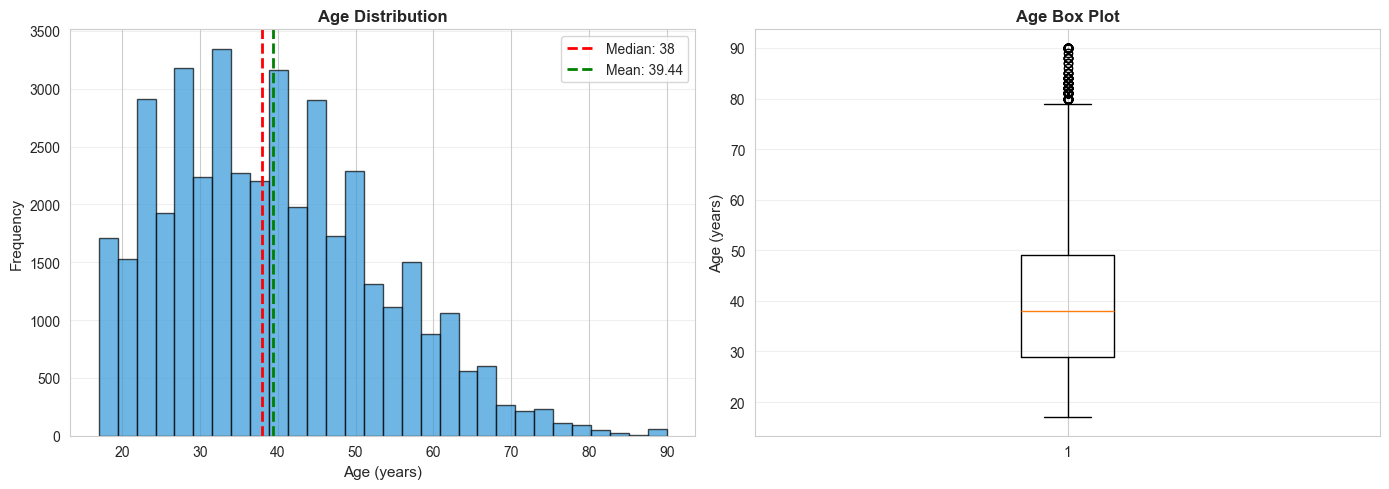

In [118]:
# Function 1:Analysis - Age
def analyze_age(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze age distribution."""
    
    print("2. ANALYSIS - AGE")

    age_stats = {
        'mean': df['age'].mean(),
        'median': df['age'].median(),
        'std': df['age'].std(),
        'min': df['age'].min(),
        'max': df['age'].max(),
        'q25': df['age'].quantile(0.25),
        'q75': df['age'].quantile(0.75)
    }
    
    print(f"\nAge Statistics:")
    for key, value in age_stats.items():
        print(f"  {key.capitalize()}: {value:.2f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(age_stats['median'], color='red', linestyle='--', linewidth=2, 
                    label=f"Median: {age_stats['median']:.0f}")
    axes[0].axvline(age_stats['mean'], color='green', linestyle='--', linewidth=2, 
                    label=f"Mean: {age_stats['mean']:.2f}")
    axes[0].set_xlabel('Age (years)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df['age'], vert=True)
    axes[1].set_ylabel('Age (years)', fontsize=11)
    axes[1].set_title('Age Box Plot', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return age_stats

age_stats = analyze_age(df_cleaned)


2. ANALYSIS - GENDER

Gender Distribution:
  Male: 27,382 (66.09%)
  Female: 14,050 (33.91%)


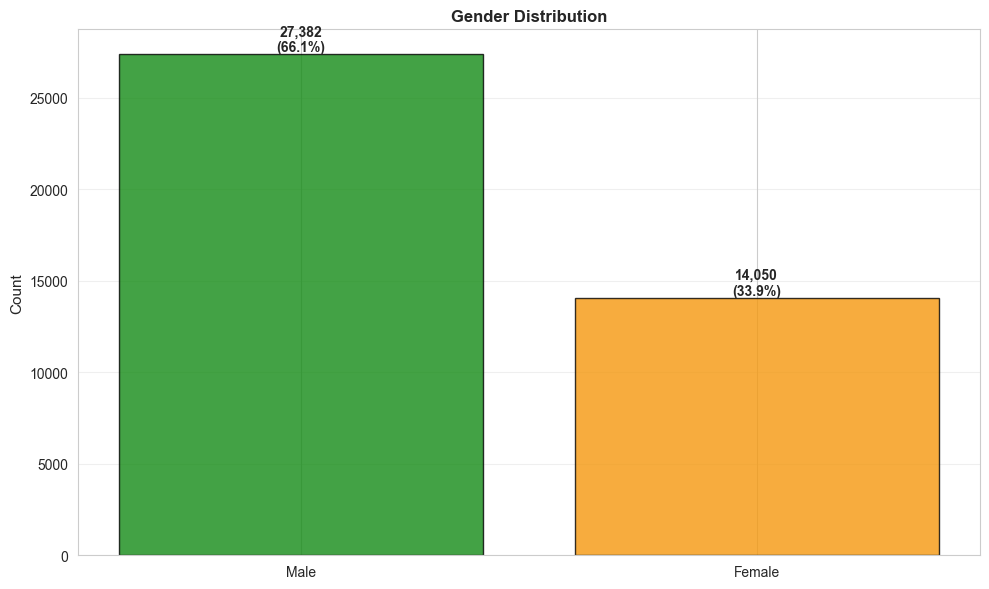

In [119]:
# function 2:Analysis - Gender
def analyze_gender(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze gender distribution."""
    print("2. ANALYSIS - GENDER")

    gender_dist = df['sex'].value_counts()
    gender_pct = df['sex'].value_counts(normalize=True) * 100
    
    print(f"\nGender Distribution:")
    for gender in gender_dist.index:
        count = gender_dist[gender]
        pct = gender_pct[gender]
        print(f"  {gender}: {count:,} ({pct:.2f}%)")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ["#148b16", "#f5980e"]
    bars = ax.bar(gender_dist.index, gender_dist.values, color=colors, 
                   edgecolor='black', alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Gender Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return gender_dist.to_dict()

gender_dist = analyze_gender(df_cleaned)


2. ANALYSIS - EDUCATION


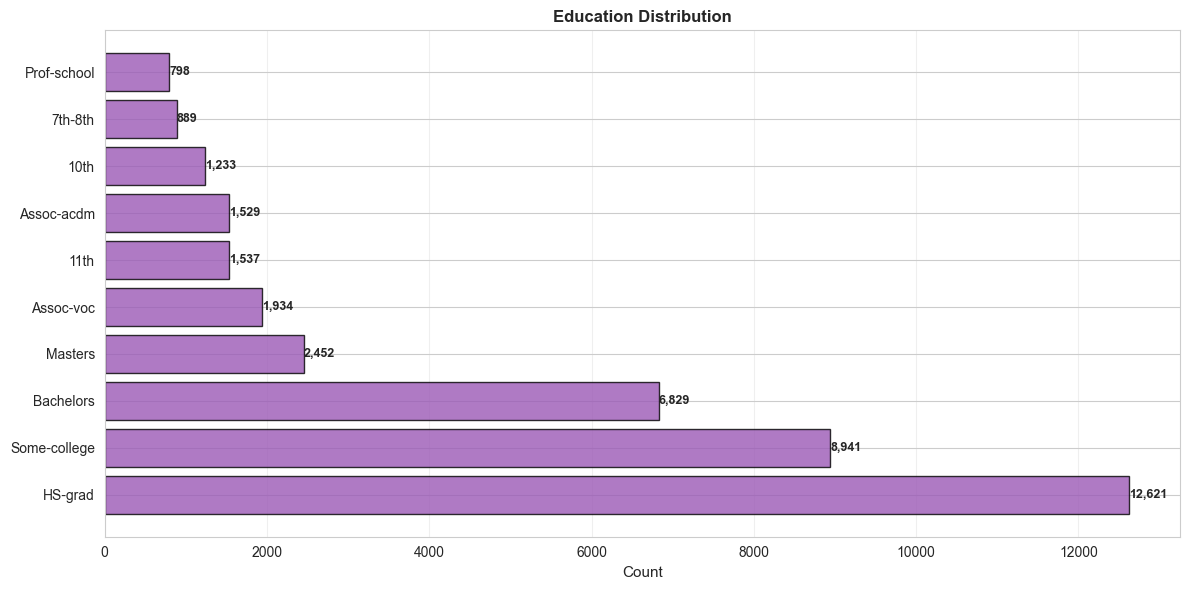

In [ ]:
# Funtion 3: Analysis - Education
def analyze_education(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze education distribution."""

    print("\n2. ANALYSIS - EDUCATION")
    
    edu_dist = df['education'].value_counts()
    
    #visualization - Top 10 only
    fig, ax = plt.subplots(figsize=(12, 6))
    top_10_edu = edu_dist.head(10)
    bars = ax.barh(range(len(top_10_edu)), np.array(top_10_edu.values), color='#9b59b6', 
                   edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_10_edu)))
    ax.set_yticklabels(top_10_edu.index.tolist())
    ax.set_xlabel('Count', fontsize=11)
    #just the top 10 categories
    ax.set_title('Education Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f'{int(width):,}',
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return edu_dist.to_dict()

edu_dist = analyze_education(df_cleaned)


ANALYSIS - INCOME

Income Distribution:
  ≤$50K (Budget): 31,127 (75.13%)
  >$50K (Premium): 10,305 (24.87%)


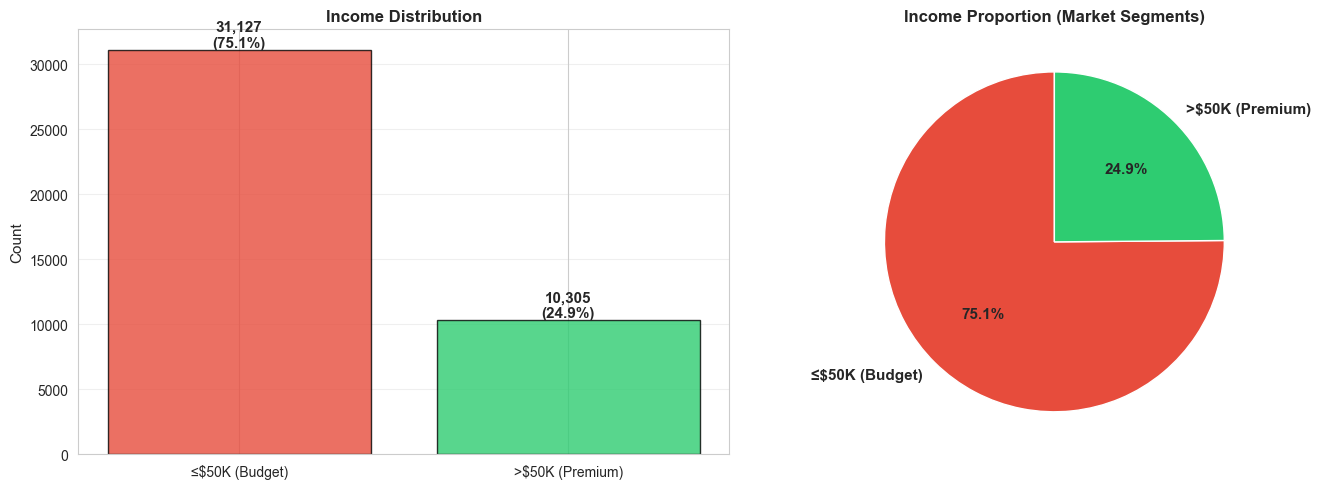

In [ ]:
# Function: Analysis - Income
def analyze_income(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze income distribution."""
    print("\nANALYSIS - INCOME")
    
    income_counts = df['income_binary'].value_counts()
    income_labels = {0: '≤$50K (Budget)', 1: '>$50K (Premium)'}
    
    print(f"\nIncome Distribution:")
    for category, count in income_counts.items():
        label = income_labels[category]
        pct = count / len(df) * 100
        print(f"  {label}: {count:,} ({pct:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    colors = ['#e74c3c', '#2ecc71']
    labels = [income_labels[i] for i in income_counts.index]
    bars = axes[0].bar(labels, income_counts.values, color=colors, 
                       edgecolor='black', alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Income Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart
    axes[1].pie(income_counts.values, labels=labels, autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Income Proportion (Market Segments)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return income_counts.to_dict()

income_dist = analyze_income(df_cleaned)

ANALYSIS - INCOME by GENDER

Income Distribution by Gender (Counts):
sex            Female   Male
income_binary               
0               12359  18768
1                1691   8614

Income Distribution by Gender (Percentages):

≤$50K (Budget):
  • Female: 39.7% (12,359)
  • Male: 60.3% (18,768)

>$50K (Premium):
  • Female: 16.4% (1,691)
  • Male: 83.6% (8,614)


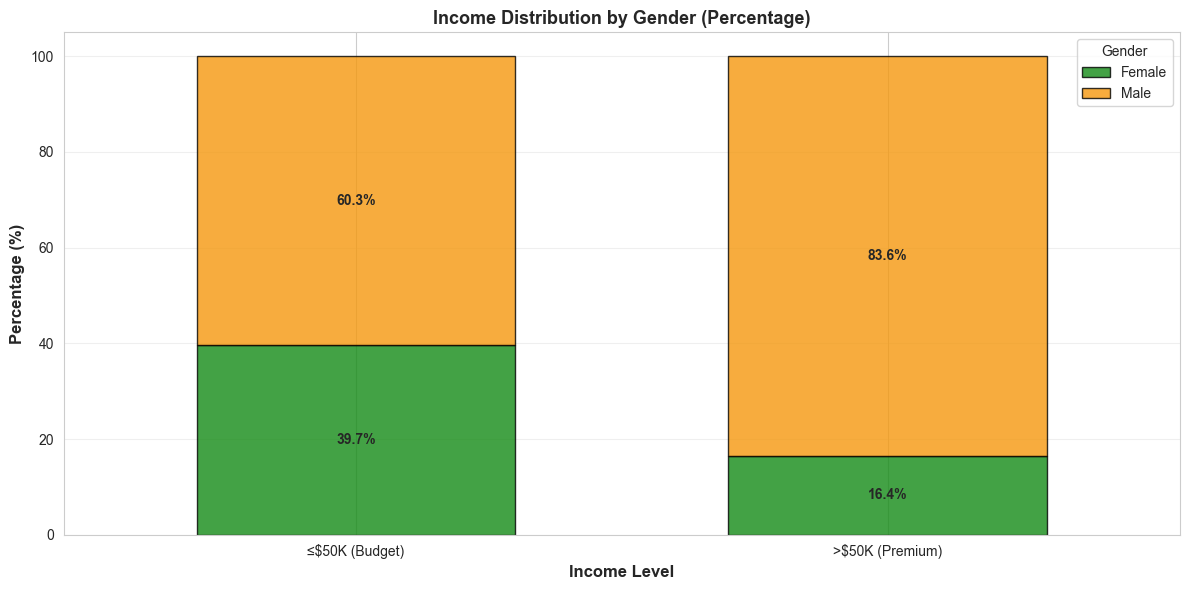

In [124]:
# Anlysis:income by Gender %
print("ANALYSIS - INCOME by GENDER")
# Calculate gender distribution within each income group
income_gender_crosstab = pd.crosstab(df_cleaned['income_binary'], df_cleaned['sex'], margins=False)
income_gender_pct = pd.crosstab(df_cleaned['income_binary'], df_cleaned['sex'], normalize='index') * 100

#labels for income categories
income_labels = {0: '≤$50K (Budget)', 1: '>$50K (Premium)'}

print("\nIncome Distribution by Gender (Counts):")
print(income_gender_crosstab)

print("\nIncome Distribution by Gender (Percentages):")
for income_cat in [0, 1]:
    label = income_labels[income_cat]
    print(f"\n{label}:")
    for gender in income_gender_pct.columns:
        pct = income_gender_pct.loc[income_cat, gender]
        count = income_gender_crosstab.loc[income_cat, gender]
        print(f"  • {gender}: {pct:.1f}% ({count:,})")

# percentage bar chart
fig, ax = plt.subplots(figsize=(12, 6))

income_gender_pct_plot = income_gender_pct.copy()
income_gender_pct_plot.index = [income_labels[i] for i in income_gender_pct_plot.index]
income_gender_pct_plot.plot(
    ax=ax,
    kind='bar',
    stacked=True,
    color=['#148b16', '#f5980e'],
    edgecolor='black',
    alpha=0.8,
    width=0.6
)

ax.set_xlabel('Income Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Income Distribution by Gender (Percentage)', fontsize=13, fontweight='bold')
ax.legend(title='Gender', loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

ANALYSIS - INCOME by EDUCATION 

 Income Distribution by Education Group:
education_group  Bachelor's+  HS Graduate  Less than HS  Some College
income                                                               
<=50K                   17.7         33.8          17.4          31.1
>50K                    49.7         20.4           3.4          26.5


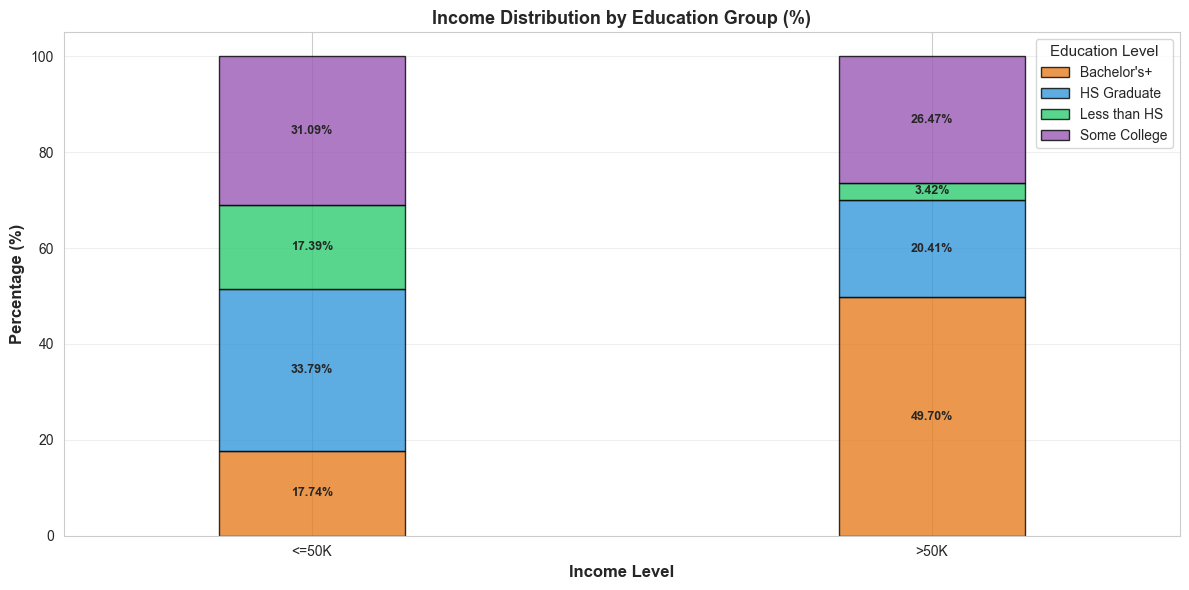

In [ ]:
# Visualize Income by Education - PERCENTAGES (4 Groups)
""" 
TEAM REVIEW: Vanessa - Cameron
How does EDUCATION affect INCOME?
Education grouped into 4 levels:
1. Less than High School (No degree)
2. High School Graduate
3. Some College/Associates
4. Bachelor's Degree or Higher (Advanced)

Why this grouping:
- Simplifies 16 education categories into meanngful segments
- Easier to see clear patterns
- Better for business decision-making

Reference: Module 4.2--professor
"""
# Group education into 4 categories
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']
    
    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"
    
print("ANALYSIS - INCOME by EDUCATION ")
# Create new education group column
df_cleaned['education_group'] = df_cleaned['education'].apply(categorize_education)

# Calculate percentages
edu_group_pct = pd.crosstab(df_cleaned['income'], df_cleaned['education_group'], normalize='index') * 100

print("\n Income Distribution by Education Group:")
print(edu_group_pct.round(1))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

edu_group_pct.plot(
    ax=ax,
    kind='bar',
    stacked=True,
    color=['#e67e22', '#3498db', '#2ecc71', '#9b59b6'],
    edgecolor='black',
    alpha=0.8,
    width=0.3
)

ax.set_xlabel('Income Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Income Distribution by Education Group (%)', fontsize=13, fontweight='bold')
ax.legend(title='Education Level', loc='upper right', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

##Need to change for a better visualization--

In [ ]:
# KEY INSIGHTS SUMMARY 
from scipy import stats

print("KEY INSIGHTS \n")

# 1. GENDER INCOME GAP ANALYSIS
print("1️⃣ GENDER INCOME GAP ANALYSIS")
print("•"*60)

premium_data = df_cleaned[df_cleaned['income_binary'] == 1]
gender_in_premium = premium_data['sex'].value_counts()
gender_in_premium_pct = (gender_in_premium / len(premium_data)) * 100

gender_gap = abs(gender_in_premium_pct.iloc[0] - gender_in_premium_pct.iloc[1])

print(f"\n>$50K Income Group Composition:")
print(f"   GENDER INCOME GAP: {gender_gap:.1f}% difference")
print(f"   • Male: {gender_in_premium_pct['Male']:.1f}%")
print(f"   • Female: {gender_in_premium_pct['Female']:.1f}%")

# Calculate z-scores for gender income disparity
male_premium_prop = gender_in_premium_pct['Male'] / 100
female_premium_prop = gender_in_premium_pct['Female'] / 100
overall_premium_prop = df_cleaned['income_binary'].mean()

male_z_score = (male_premium_prop - overall_premium_prop) / np.sqrt(overall_premium_prop * (1 - overall_premium_prop) / len(df_cleaned[df_cleaned['sex'] == 'Male']))
female_z_score = (female_premium_prop - overall_premium_prop) / np.sqrt(overall_premium_prop * (1 - overall_premium_prop) / len(df_cleaned[df_cleaned['sex'] == 'Female']))

print(f"\n  Z-Score Analysis:")
print(f"   • Male Z-Score: {male_z_score:.2f}")
print(f"   • Female Z-Score: {female_z_score:.2f}")

# 2. EDUCATION IMPACT ANALYSIS
print("\n2️⃣ EDUCATION IMPACT ON INCOME")
print("•"*60)

print("\n Premium Income Rate by Education Group:")
edu_premium_rates = []
for edu_group in ['Less than HS', 'HS Graduate', 'Some College', "Bachelor's+"]:
    premium_count = len(df_cleaned[(df_cleaned['education_group'] == edu_group) & 
                                     (df_cleaned['income_binary'] == 1)])
    total_count = len(df_cleaned[df_cleaned['education_group'] == edu_group])
    premium_pct = (premium_count / total_count) * 100 if total_count > 0 else 0
    
    edu_premium_rates.append((edu_group, premium_pct))
    print(f"   {edu_group:<20}: {premium_pct:>6.1f}% earn >$50K")

min_rate = min(edu_premium_rates, key=lambda x: x[1])
max_rate = max(edu_premium_rates, key=lambda x: x[1])
education_gap = max_rate[1] - min_rate[1]

print(f"\n✓ EDUCATION IMPACT: {education_gap:.1f}% difference")

# Calculate skewness for education impact
edu_rates = [rate[1] for rate in edu_premium_rates]
skewness = stats.skew(edu_rates)
print(f" Skewness: {skewness:.2f} ({'Right-skewed (positive)' if skewness > 0 else 'Left-skewed (negative)'})")

# 3. AGE IMPACT ANALYSIS
print("\n3️⃣ AGE IMPACT ON INCOME")
print("•"*60)

budget_age = df_cleaned[df_cleaned['income_binary'] == 0]['age'].mean()
premium_age = df_cleaned[df_cleaned['income_binary'] == 1]['age'].mean()
age_gap = premium_age - budget_age
budget_age_rounded = int(round(budget_age))
premium_age_rounded = int(round(premium_age))
age_gap_rounded = premium_age_rounded - budget_age_rounded

# Calculate age range (quartiles for more context)
budget_age_q1 = df_cleaned[df_cleaned['income_binary'] == 0]['age'].quantile(0.25)
budget_age_q3 = df_cleaned[df_cleaned['income_binary'] == 0]['age'].quantile(0.75)
premium_age_q1 = df_cleaned[df_cleaned['income_binary'] == 1]['age'].quantile(0.25)
premium_age_q3 = df_cleaned[df_cleaned['income_binary'] == 1]['age'].quantile(0.75)

print(f"\n Average Age:")
print(f" • Budget (≤$50K): {budget_age_rounded} years")
print(f" • Premium (>$50K): {premium_age_rounded} years")

print(f"\n   Age Range (25th - 75th Percentile):")
print(f"   • Budget Segment: {int(budget_age_q1)} - {int(budget_age_q3)} years")
print(f"   • Premium Segment: {int(premium_age_q1)} - {int(premium_age_q3)} years")

# Calculate skewness for age distribution
age_skewness_budget = stats.skew(df_cleaned[df_cleaned['income_binary'] == 0]['age'])
age_skewness_premium = stats.skew(df_cleaned[df_cleaned['income_binary'] == 1]['age'])

print(f"\n Age Distribtion Skewness:")
print(f" • Budget Segment: {age_skewness_budget:.2f}")
print(f" • Premium Segment: {age_skewness_premium:.2f}")


KEY INSIGHTS 

1️⃣ GENDER INCOME GAP ANALYSIS
••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

>$50K Income Group Composition:
   GENDER INCOME GAP: 67.2% difference
   • Male: 83.6%
   • Female: 16.4%

  Z-Score Analysis:
   • Male Z-Score: 224.78
   • Female Z-Score: -23.21

2️⃣ EDUCATION IMPACT ON INCOME
••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

 Premium Income Rate by Education Group:
   Less than HS        :    6.1% earn >$50K
   HS Graduate         :   16.7% earn >$50K
   Some College        :   22.0% earn >$50K
   Bachelor's+         :   48.1% earn >$50K

✓ EDUCATION IMPACT: 42.0% difference
 Skewness: 0.68 (Right-skewed (positive))

3️⃣ AGE IMPACT ON INCOME
••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••

 Average Age:
 • Budget (≤$50K): 38 years
 • Premium (>$50K): 44 years

   Age Range (25th - 75th Percentile):
   • Budget Segment: 26 - 47 years
   • Premium Segment: 36 - 51 years

   Age Distribution Skewness:
   • Budget Segmen

/var/folders/_x/91hn0bv175n56mgwdc2zs2n40000gp/T/ipykernel_67259/657139469.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['≤$50K (Budget)', '>$50K (Premium)'])


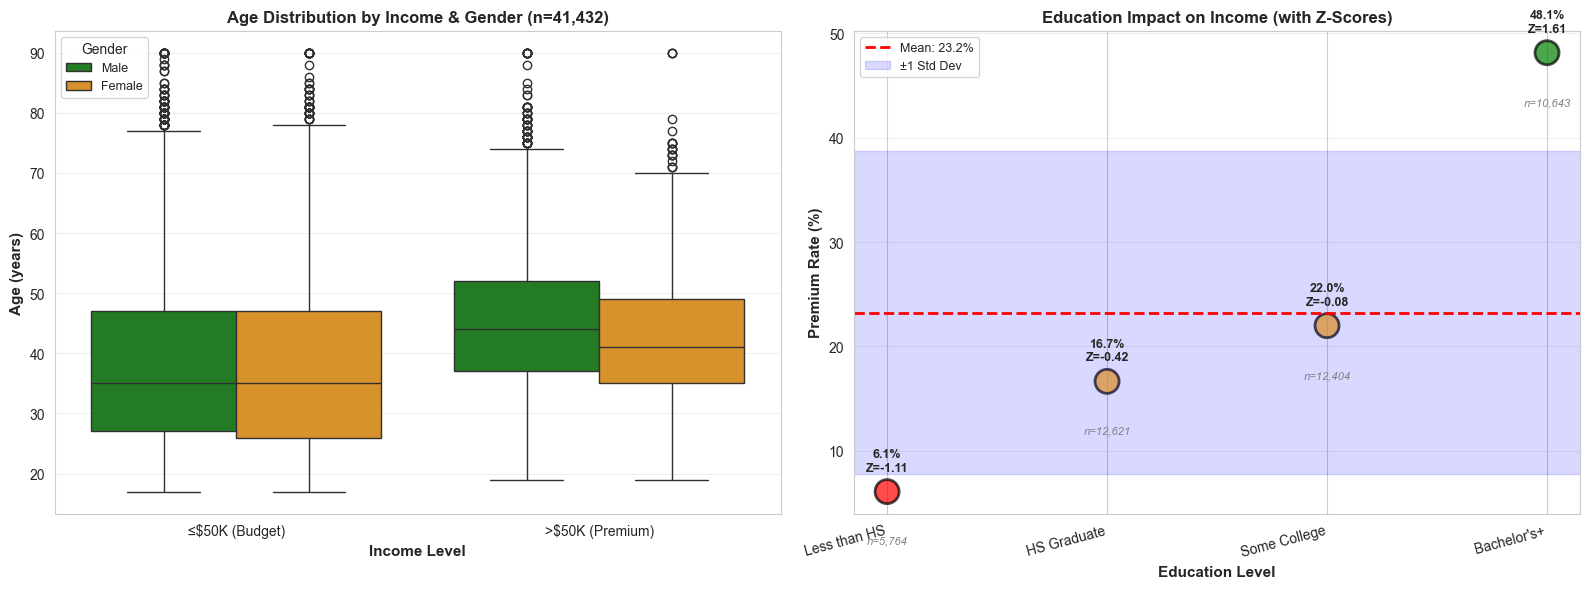

In [ ]:
# 4. VISUALIZATION: Box Plot + Education Scatter
from scipy import stats
""""
reference :https://pandas.pydata.org/docs/reference/api/pandas.plotting.boxplot.html 
"""""
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Box Plot - Age by Income & Gender
plot_data = df_cleaned[['age', 'income', 'sex']].copy()

sns.boxplot(data=plot_data, x='income', y='age', hue='sex',
            palette={'Male': '#148b16', 'Female': '#f5980e'},
            ax=axes[0])

axes[0].set_xlabel('Income Level', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Age (years)', fontsize=11, fontweight='bold')
axes[0].set_title(f'Age Distribution by Income & Gender (n={len(df_cleaned):,})', 
                  fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['≤$50K (Budget)', '>$50K (Premium)'])
axes[0].legend(title='Gender', loc='upper left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# PLOT 2: Education Impact with Z-Scores
edu_nums = [0, 1, 2, 3]
edu_labels_list = ['Less than HS', 'HS Graduate', 'Some College', "Bachelor's+"]
premium_rates_list = [rate[1] for rate in edu_premium_rates]

# Calculate z-scores
edu_z_scores = stats.zscore(premium_rates_list)
colors_z = ['red' if z < -1 else 'orange' if z < 0 else 'lightgreen' if z < 1 else 'green' for z in edu_z_scores]

# Scatter plot
axes[1].scatter(edu_nums, premium_rates_list, s=300, c=colors_z, alpha=0.7, 
                edgecolors='black', linewidth=2)

# labels with z-scores
for i, (edu, rate, z_score) in enumerate(zip(edu_labels_list, premium_rates_list, edu_z_scores)):
    axes[1].text(i, rate + 2, f'{rate:.1f}%\nZ={z_score:.2f}', 
                 ha='center', fontsize=9, fontweight='bold')
    
    # Sample size
    n = len(df_cleaned[df_cleaned['education_group'] == edu])
    axes[1].text(i, rate - 5, f'n={n:,}', ha='center', fontsize=8, 
                 style='italic', color='gray')

# Mean 
axes[1].axhline(y=np.mean(premium_rates_list), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(premium_rates_list):.1f}%')

# Std dev shade
axes[1].axhspan(np.mean(premium_rates_list) - np.std(premium_rates_list), 
                np.mean(premium_rates_list) + np.std(premium_rates_list),
                alpha=0.15, color='blue', label='±1 Std Dev')

axes[1].set_xticks(edu_nums)
axes[1].set_xticklabels(edu_labels_list, rotation=15, ha='right')
axes[1].set_xlabel('Education Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Premium Rate (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Education Impact on Income (with Z-Scores)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:

# 5. OUR CRITICAL FINDINGS SUMMARY

print("CRITICAL FINDINGS:")
print(f"\n1. GENDER INCOME GAP")
print(f"   • Premium segment (>$50K) is {gender_in_premium_pct['Male']:.1f}% Male")
print(f"   • Gap of {gender_gap:.1f}% indicates significant disparity")
print(f"   • Z-Scores confirm statistical significance")

print(f"\n2. EDUCATION = STRONGEST PREDICTOR")
print(f"   • Premium rate jumps {education_gap:.1f}% from {min_rate[0]} to {max_rate[0]}")
print(f"   • Skewness {skewness:.3f} shows strong positive relationship")
print(f"   • {max_rate[0]} have {max_rate[1]:.1f}% premium buyer rate")

print(f"\n3. AGE MATTERS")
print(f"   • Premium buyers are {age_gap:.1f} years older")
print(f"   • Age-income relationship visible in scatter plot")

print("\n✓ Target Audience:")
print("   Primary: College graduates (Bachelor's+) earning >$50K")
print("   Secondary: Professionals aged 40+")

CRITICAL FINDINGS:

1. GENDER INCOME GAP
   • Premium segment (>$50K) is 83.6% Male
   • Gap of 67.2% indicates significant disparity
   • Z-Scores confirm statistical significance

2. EDUCATION = STRONGEST PREDICTOR
   • Premium rate jumps 42.0% from Less than HS to Bachelor's+
   • Skewness 0.685 shows strong positive relationship
   • Bachelor's+ have 48.1% premium buyer rate

3. AGE MATTERS
   • Premium buyers are 6.6 years older
   • Age-income relationship visible in scatter plot

✓ Target Audience:
   Primary: College graduates (Bachelor's+) earning >$50K
   Secondary: Professionals aged 40+
